# ResNet50 Training on C-NMC 2019 Dataset



In [1]:
# Install optional packages
!pip -q install torchinfo seaborn

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchinfo import summary


In [3]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [4]:
# Dataset path
data_dir = '/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)'

# Image transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
print('Classes:', dataset.classes)

Classes: ['all', 'normal']


In [5]:
# Count images per class
class_counts = {}

for idx, class_name in enumerate(dataset.classes):
    class_counts[class_name] = dataset.targets.count(idx)

# Create dataframe
table1a = pd.DataFrame(list(class_counts.items()),
                       columns=["Class","Number of Images"])

print("Table 1(a): Per Class Distribution")
display(table1a)

Table 1(a): Per Class Distribution


,Class,Number of Images
0,all,7272
1,normal,3389


In [6]:
# Train/Validation/Test split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(len(train_dataset), len(val_dataset), len(test_dataset))

7462 1599 1600


In [7]:
import pandas as pd
from collections import Counter

# Get label indices from subsets
train_labels = [dataset.targets[i] for i in train_dataset.indices]
val_labels = [dataset.targets[i] for i in val_dataset.indices]
test_labels = [dataset.targets[i] for i in test_dataset.indices]

# Count class distribution
train_dist = Counter(train_labels)
val_dist = Counter(val_labels)
test_dist = Counter(test_labels)

# Create table
table1c = pd.DataFrame({
    "Train":[train_dist[i] for i in range(len(dataset.classes))],
    "Validation":[val_dist[i] for i in range(len(dataset.classes))],
    "Test":[test_dist[i] for i in range(len(dataset.classes))]
}, index=dataset.classes)

print("Table 1(c): Class Distribution per Split")
display(table1c)


Table 1(c): Class Distribution per Split


,Train,Validation,Test
all,5034,1118,1120
normal,2428,481,480


In [8]:
# Load ResNet50
model = models.resnet50(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

summary(model, input_size=(32,3,224,224))

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 2]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          4,096
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│ 

In [9]:
import pandas as pd

table2 = pd.DataFrame({
"Parameter":["Loss Function","Optimizer","Learning Rate","Batch Size","Epoch","Model"],
"Value":["CrossEntropyLoss","Adam","0.001","32","20","ResNet50"]
})

print("Table 2: Training Parameters")
display(table2)

Table 2: Training Parameters


,Parameter,Value
0,Loss Function,CrossEntropyLoss
1,Optimizer,Adam
2,Learning Rate,0.001
3,Batch Size,32
4,Epoch,20
5,Model,ResNet50


In [10]:
# Training function
def train_model(model, train_loader, val_loader, epochs=20):

    train_loss_history=[]
    val_loss_history=[]
    train_acc_history=[]
    val_acc_history=[]

    for epoch in range(epochs):

        model.train()
        running_loss=0
        correct=0
        total=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)
            loss=criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(pred==labels).sum().item()

        train_loss=running_loss/len(train_loader)
        train_acc=100*correct/total

        model.eval()

        val_loss=0
        val_correct=0
        val_total=0

        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)
                loss=criterion(outputs,labels)

                val_loss+=loss.item()

                _,pred=torch.max(outputs,1)

                val_total+=labels.size(0)
                val_correct+=(pred==labels).sum().item()

        val_loss/=len(val_loader)
        val_acc=100*val_correct/val_total

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}%")

    return train_loss_history,val_loss_history,train_acc_history,val_acc_history

In [11]:
train_loss_history,val_loss_history,train_acc_history,val_acc_history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=20
    
)

Epoch 1: Train Loss 0.3281 | Val Loss 0.3517 | Train Acc 86.57% | Val Acc 84.80%
Epoch 2: Train Loss 0.2158 | Val Loss 0.2807 | Train Acc 91.46% | Val Acc 88.99%
Epoch 3: Train Loss 0.1704 | Val Loss 0.3970 | Train Acc 93.69% | Val Acc 82.11%
Epoch 4: Train Loss 0.1413 | Val Loss 0.2749 | Train Acc 94.77% | Val Acc 87.62%
Epoch 5: Train Loss 0.1265 | Val Loss 0.2921 | Train Acc 95.66% | Val Acc 87.93%
Epoch 6: Train Loss 0.1063 | Val Loss 0.1790 | Train Acc 95.77% | Val Acc 93.25%
Epoch 7: Train Loss 0.0825 | Val Loss 0.1408 | Train Acc 97.33% | Val Acc 94.68%
Epoch 8: Train Loss 0.0716 | Val Loss 0.3661 | Train Acc 97.41% | Val Acc 90.31%
Epoch 9: Train Loss 0.0717 | Val Loss 0.1791 | Train Acc 97.28% | Val Acc 93.56%
Epoch 10: Train Loss 0.0464 | Val Loss 0.4331 | Train Acc 98.31% | Val Acc 86.05%
Epoch 11: Train Loss 0.0405 | Val Loss 0.2288 | Train Acc 98.45% | Val Acc 93.93%
Epoch 12: Train Loss 0.0517 | Val Loss 0.1577 | Train Acc 98.06% | Val Acc 93.50%
Epoch 13: Train Loss 0.03

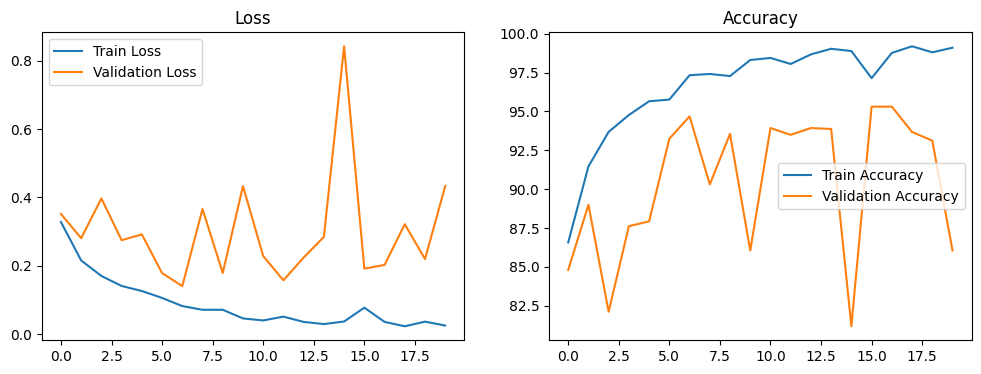

In [12]:
# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss_history,label='Train Loss')
plt.plot(val_loss_history,label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_acc_history,label='Train Accuracy')
plt.plot(val_acc_history,label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

              precision    recall  f1-score   support

         all       0.96      0.86      0.91      1120
      normal       0.74      0.92      0.82       480

    accuracy                           0.88      1600
   macro avg       0.85      0.89      0.86      1600
weighted avg       0.89      0.88      0.88      1600



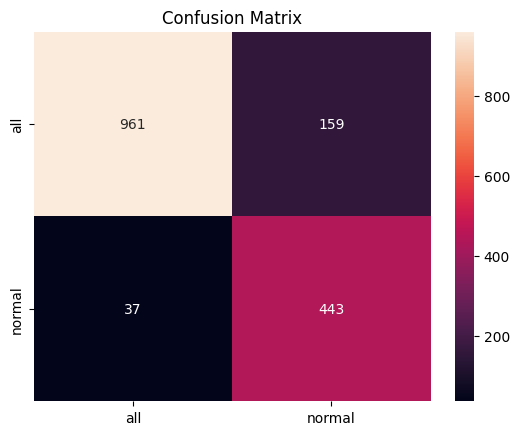

In [13]:
# Test evaluation
model.eval()
y_true=[]
y_pred=[]

with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        outputs=model(images)
        _,pred=torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred.cpu().numpy())

print(classification_report(y_true,y_pred,target_names=dataset.classes))

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=dataset.classes,yticklabels=dataset.classes)
plt.title('Confusion Matrix')
plt.show()